In [1]:
import scarf

scarf.set_verbosity('WARNING')

In [2]:
scarf.cytebase.connect("scarf_docs").download_dataset(
    name='tenx_10K_pbmc-v1_atacseq',
    destination='scarf_datasets'
)

PosixPath('/tmp/tmpc3p26at6/scarf_datasets/tenx_10K_pbmc-v1_atacseq')

In [3]:
reader = scarf.CrH5Reader(
    'scarf_datasets/tenx_10K_pbmc-v1_atacseq/data.h5'
)
reader.assayFeats

,ATAC
type,Peaks
start,0
end,89796
nFeatures,89796


In [4]:
writer = scarf.CrToZarr(
    reader,
    zarr_loc=f'scarf_datasets/tenx_10K_pbmc-v1_atacseq/data.zarr',
    chunk_size=(1000, 2000)
)
writer.dump(batch_size=1000)

In [5]:
ds = scarf.DataStore(
    'scarf_datasets/tenx_10K_pbmc-v1_atacseq/data.zarr', 
    nthreads=4
)

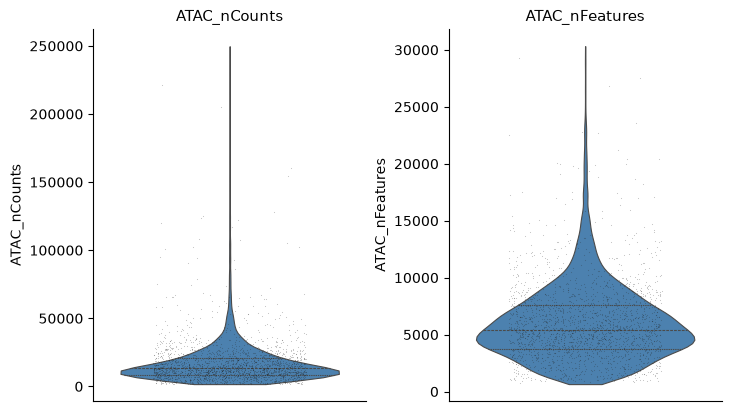

PlotResult(axes=2, tables=2, legends=1, scales=0, owns_figure=True, rendered=True)

In [6]:
qc_cols = [
    c for c in ('ATAC_nCounts', 'ATAC_nFeatures')
    if c in ds.cells.columns
]
ds.plots.distribution(
    keys=qc_cols,
    kind='violin',
    max_points=2000,
)

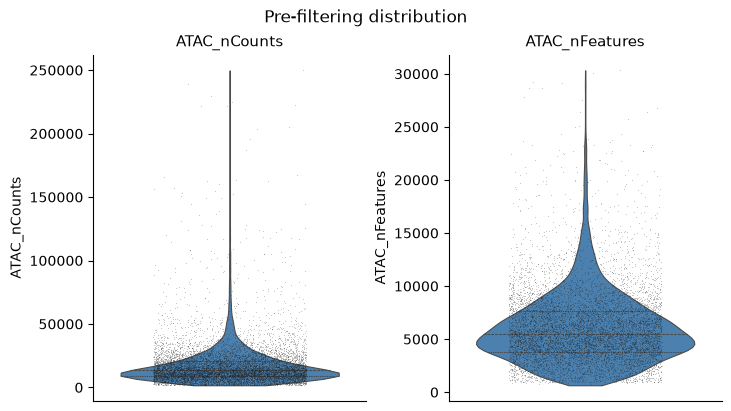

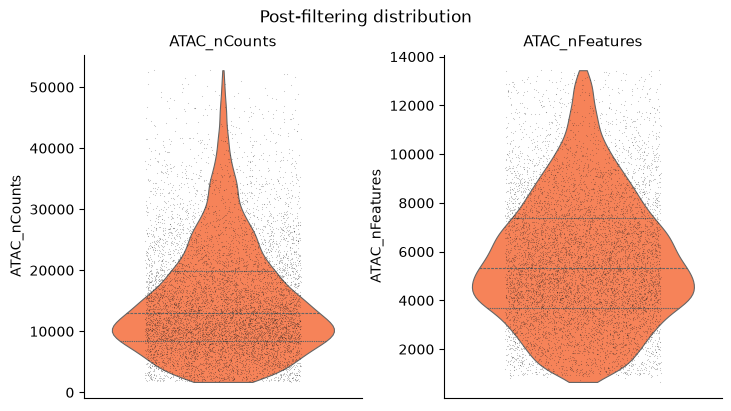

In [7]:
ds.auto_filter_cells(show_qc_plots=True)

In [8]:
ds.mark_prevalent_peaks(top_n=25000)

In [9]:
ds.ATAC.feats.head()

,I,ids,names,nCells,dropOuts,I__prevalent_peaks,stats_I_prevalence
0,True,chr1:565107-565550,chr1:565107-565550,83,8645,False,0.206181
1,True,chr1:569174-569639,chr1:569174-569639,199,8529,False,0.350725
2,True,chr1:713460-714823,chr1:713460-714823,2486,6242,True,1.993573
3,True,chr1:752422-753038,chr1:752422-753038,432,8296,True,0.680701
4,True,chr1:762106-763359,chr1:762106-763359,1878,6850,True,1.570790


In [10]:
normalized = ds.run_normalization(feat_key='prevalent_peaks')
lsi = ds.run_lsi(normalized, dims=50, skip_first=True)
ds.build_embedding_initialization(lsi)
ann = ds.build_ann_index(lsi)
neighbors = ds.query_neighbors(ann, k=21)
ds.build_connectivity_map(neighbors)

ArtifactRef(scope='assay', kind='connectivity_map', artifact_id='42af5e95b3a4a56cde9325a112394df68e342c464ec6b76edc22f6e6e4cd2c3c', assay='ATAC')

In [11]:
ds.run_umap(
    n_epochs=500,
    min_dist=0.1, 
    spread=1, 
    parallel=True
)

In [12]:
ds.run_leiden_clustering(resolution=0.6)

In [13]:
ds.cells.head()

,I,ids,names,ATAC_nCounts,ATAC_UMAP2,ATAC_leiden_cluster,ATAC_nFeatures,ATAC_UMAP1
0,True,AAACGAAAGAGCGAAA-1,AAACGAAAGAGCGAAA-1,13187.0,-9.724500,1,5546.0,3.458691
1,True,AAACGAAAGAGTTTGA-1,AAACGAAAGAGTTTGA-1,16074.0,-12.826056,5,6586.0,4.504020
2,True,AAACGAAAGCGAGCTA-1,AAACGAAAGCGAGCTA-1,28009.0,9.360368,9,9214.0,3.300084
3,False,AAACGAAAGGCTTCGC-1,AAACGAAAGGCTTCGC-1,221747.0,NaN,-1,30325.0,NaN
4,True,AAACGAAAGTGCTGAG-1,AAACGAAAGTGCTGAG-1,11440.0,-8.940671,2,4922.0,3.298625


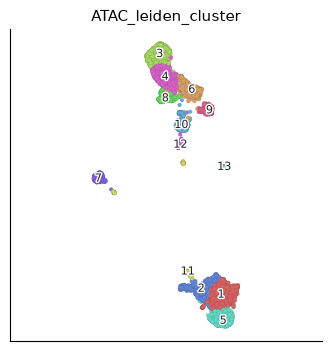

PlotResult(axes=1, tables=0, legends=1, scales=2, owns_figure=True, rendered=True)

In [14]:
ds.plots.embedding(
    layout_key='ATAC_UMAP',
    color_by='ATAC_leiden_cluster',
)

In [15]:
scarf.cytebase.connect("scarf_docs").download_dataset(
    name='annotations',
    destination='scarf_datasets'
)

PosixPath('/tmp/tmpc3p26at6/scarf_datasets/annotations')

In [16]:
ds.add_melded_assay(
    from_assay='ATAC',
    external_bed_fn='scarf_datasets/annotations/human_GRCh37_gencode_v38_gene_body.bed.gz',
    peaks_col='ids',
    renormalization=False,
    assay_label='GeneScores',
    assay_type='RNA'
)

Chromosome chrM not in the input peak coordinates



Minimum cell count (6.539499236477921) is lower than size factor multiplier (1000)



In [17]:
ds

DataStore has 8426 (8728) cells with 2 assays: ATAC GeneScores
   Cell metadata:
            'I', 'ids', 'names', 'GeneScores_percentMito', 'GeneScores_percentRibo', 
            'ATAC_nFeatures', 'ATAC_nCounts', 'ATAC_UMAP2', 'GeneScores_nCounts', 'GeneScores_nFeatures', 
            'ATAC_leiden_cluster', 'ATAC_UMAP1'
   ATAC assay has 86049 (89796) features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'nCells', 
            'I__prevalent_peaks'
   GeneScores assay has 28357 (62446) features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'nCells', 
          

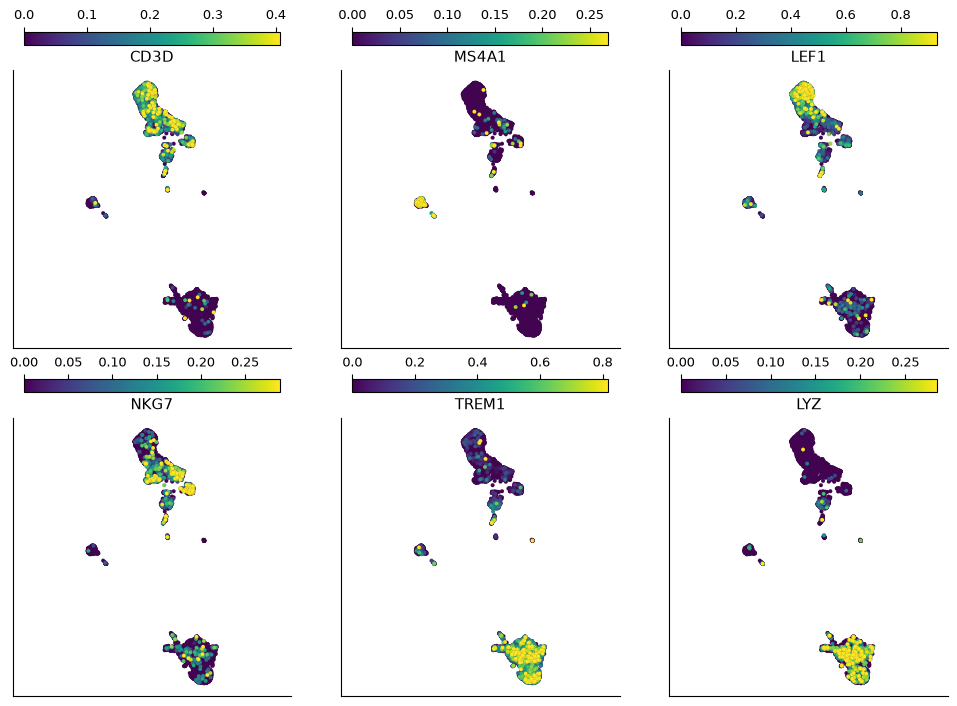

PlotResult(axes=6, tables=0, legends=6, scales=6, owns_figure=True, rendered=True)

In [18]:
ds.plots.embedding(
    layout_key='ATAC_UMAP',
    from_assay='GeneScores',
    color_by=['CD3D', 'MS4A1', 'LEF1', 'NKG7', 'TREM1', 'LYZ'],
    clip_fraction=0.01,
    n_columns=3,
    sort_values=True,
)